# AI1013: Programming for AI
## Assignment 4

### 1. K-Means Clustering

#### 1.1 Dataset Generation

Importing libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Generating first semicircle

In [2]:
np.random.seed(123) #reproducable

theta = np.linspace(0, np.pi, 500)

#x
semicircle1_x = np.cos(theta)
noise1_x = np.random.normal(0,0.1, 500)

#y
semicircle1_y = np.sin(theta)
noise1_y = np.random.normal(0,0.1,500)

#adding noise
semicircle1_x += noise1_x
semicircle1_y += noise1_y

Generating second semicircle

In [3]:
#x
semicircle2_x = 1 + np.cos(theta)
noise2_x = np.random.normal(0,0.1, 500)

#y
semicircle2_y = -np.sin(theta)
noise2_y = np.random.normal(0,0.1,500)

#adding noise
semicircle2_x += noise2_x
semicircle2_y += noise2_y

Plotting the generated points

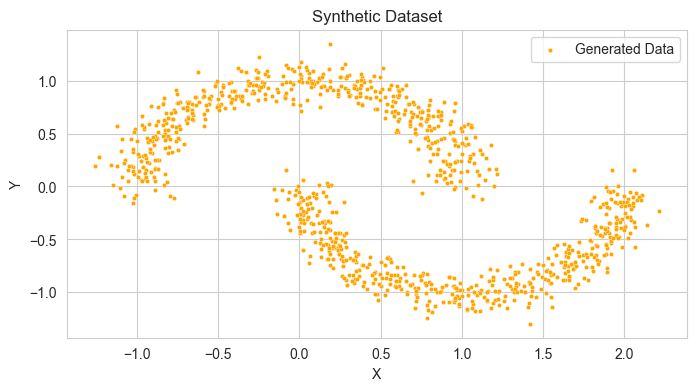

In [4]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 4))
sns.scatterplot(x=semicircle1_x, y=semicircle1_y, s=10, color='orange', label='Generated Data')
sns.scatterplot(x = semicircle2_x, y=semicircle2_y, s=10, color='orange')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Synthetic Dataset')
plt.legend()
plt.show()

storing data points as tuples

In [5]:
d1 = [(x,y) for x,y in zip(semicircle1_x, semicircle1_y)]
d2 = [(x,y) for x,y in zip(semicircle2_x, semicircle2_y)]

data_points = d1 + d2


print(data_points)

[(np.float64(0.8914369396699439), np.float64(0.07520336682672812)), (np.float64(1.0997147263206788), np.float64(0.013259810218771439)), (np.float64(1.0282185772400134), np.float64(-0.013953341491120704)), (np.float64(0.8491921682822404), np.float64(0.11184465464680945)), (np.float64(0.9418228971106825), np.float64(0.1512625726428147)), (np.float64(1.1646482345432838), np.float64(0.16521906828270758)), (np.float64(0.756618697981703), np.float64(-0.06126179072717729)), (np.float64(0.9561377925233946), np.float64(-0.009388547019140978)), (np.float64(1.1253255161772238), np.float64(-0.11980468634974047)), (np.float64(0.911721098566111), np.float64(0.03277517513929419)), (np.float64(0.9301301990523698), np.float64(0.10452856755064874)), (np.float64(0.9881320345950988), np.float64(0.05591808400647662)), (np.float64(1.1462864697118962), np.float64(0.2685625607306456)), (np.float64(0.9327623594296575), np.float64(0.04116941740668615)), (np.float64(0.9517199111382401), np.float64(-0.02082406018

Now, we have our synthetic dataset ready.

#### 1.2 K-Means Clustering

Initializing our centroids

In [6]:
C_1 = ( -2 + 5*np.random.uniform(), -2 + 4*np.random.uniform() )
C_2 = ( -2 + 5*np.random.uniform(), -2 + 4*np.random.uniform() )

print(C_1, C_2)

(0.055187726196818776, -0.5255277638362532) (1.450015737419812, 0.9676344957337135)


Initializing `mappings` dictionary

In [7]:
mappings={}

for point in data_points:
    distance1 = np.sqrt((point[0]-C_1[0])**2 + (point[1]-C_1[1])**2)
    distance2 = np.sqrt((point[0]-C_2[0])**2 + (point[1]-C_2[1])**2)

    if(distance1 < distance2):
        mappings[point] = 1
    elif(distance1 > distance2):
        mappings[point] = 2
    else: #tie case
        mappings[point] = np.random.choice([1,2])


Setting up for iterating

In [8]:
num_points_updated = 0 #to track cluster of how many points changed in this iteration 

max_iters = 10000
current_iters = 0

Executing the algorithm

In [9]:
for iteration in range(max_iters):
    num_points_updated=0
    updated_mappings = {}
    for point in data_points:
        distance1 = np.sqrt((point[0]-C_1[0])**2 + (point[1]-C_1[1])**2)
        distance2 = np.sqrt((point[0]-C_2[0])**2 + (point[1]-C_2[1])**2)

        if(distance1 < distance2):
            updated_mappings[point] = 1
        elif(distance1 > distance2):
            updated_mappings[point] = 2
        else: #tie case
            updated_mappings[point] = np.random.choice([1,2])

        #checking if the label is updated
        if updated_mappings[point] != mappings[point]:
            num_points_updated+=1

    #updating to updated_mappings
    mappings = updated_mappings

    #checking for condition
    if(num_points_updated==0 and current_iters):
        print(f"Converged in {current_iters} iterations.")
        break

    #increasing the number of iterations
    current_iters+=1

    
    # updating centroids
    cluster1_points_x = []
    cluster1_points_y = []
    cluster2_points_x = []
    cluster2_points_y = []

    for point in data_points:
        if mappings[point]==1:
            cluster1_points_x.append(point[0])
            cluster1_points_y.append(point[1])
        else:
            cluster2_points_x.append(point[0])
            cluster2_points_y.append(point[1])

    C_1 = (np.mean(cluster1_points_x), np.mean(cluster1_points_y))
    C_2 = (np.mean(cluster2_points_x), np.mean(cluster2_points_y))

Converged in 10 iterations.


The clustering is completed, lets plot them

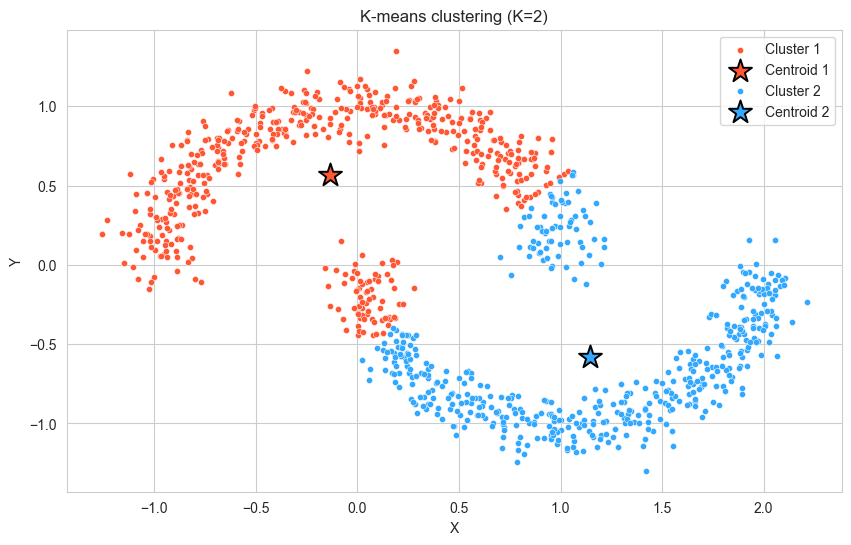

In [10]:
cluster1_points_x = []
cluster1_points_y = []
cluster2_points_x = []
cluster2_points_y = []

for point in data_points:
    if mappings[point] == 1:
        cluster1_points_x.append(point[0])
        cluster1_points_y.append(point[1])
    else:
        cluster2_points_x.append(point[0])
        cluster2_points_y.append(point[1])

#plotting
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.scatterplot(x=cluster1_points_x, y=cluster1_points_y, s=20, color='#FF5733', label='Cluster 1')
sns.scatterplot(x=[C_1[0]], y=[C_1[1]], s=300, marker='*', color='#FF5733',edgecolor="black", label='Centroid 1')

sns.scatterplot(x = cluster2_points_x, y=cluster2_points_y, s=20, color='#33A8FF', label="Cluster 2")
sns.scatterplot(x=[C_2[0]], y=[C_2[1]], s=300, marker='*', color='#33A8FF',edgecolor="black", label='Centroid 2')


plt.xlabel('X')
plt.ylabel('Y')
plt.title('K-means clustering (K=2)')
plt.legend()
plt.show()

The clustering comes out to be pretty well, but not exact as suggested by the Note in the PDF.

### 2. K-Means++ Clustering on the `Covertype` Dataset

#### 2.1 Data Preparation

Importing required tools

In [11]:
from sklearn.datasets import fetch_covtype

Loading the data <a id="seed"></a>

In [12]:
#loading dataset
dataset = fetch_covtype()

#seed
random_generator = np.random.default_rng(seed=42)

#subsampling
indices = random_generator.choice(range(len(dataset.target)), 20000, replace=False)
X = dataset.data[indices]
y = dataset.target[indices]

Lets standardize the quantitative features. We know the standardize version $z$ is given by
$$z = \frac{(x-\mu)}{\sigma}$$
where, $\mu$ is the sample mean and $\sigma$ is the standard deviation.

In [13]:
X[:, :10] = X[:, :10] - np.mean(X[:, :10], axis=0)
X[:, :10] = X[:,:10] / np.std(X[:, :10], axis=0)

Lets verify the shape of $X$

In [14]:
X.shape

(20000, 54)

Clearly, $X \in \mathbb{R}^{20000 \times 54}$, as expected

#### 2.2 Implementing K-Means++

Defining functions to initialize the centroids according to the k-means++.

In [15]:
def kmeans_plus_plus_init(X, k, random_generator, naive_centroids=False):
    if naive_centroids:
        centroids = X[random_generator.choice(len(X), k, replace=False)]
        return centroids

    #else do kmeans++
    centroids = [X[random_generator.choice(len(X))]]
    
    for i in range(k-1):
        squared_distances = np.min( [np.sum((X-centroids[j])**2, axis=1) for j in range(len(centroids))], axis=0)
        # squared_distances = np.min(squared_distances, axis=0)

        probability_points = squared_distances / np.sum(squared_distances)

        centroids.append(X[random_generator.choice(len(X), p=probability_points)])
    
    return np.array(centroids)

Now Lets define a function that does the vanilla K-means clustering.

Note that we are only calculating distance squared, not their square root as it will
- Decrease the calculation time
- Help to calculate WC-SSD without extra calculations

Also, for calculation of squared distances, we can make it faster by doing some precomputations, as explained.

We have,
$$ ||x-c||^2 = ||x||^2 + ||c||^2 - 2 x\cdot c$$

Now, here the value $||x||^2$ will always remain same for all runs of the function. So we can calculate these values once and then reuse them again and again, making our program run faster.

In [16]:
def k_means_clustering(X,X_norm_squared, centroids, max_iters, to_print=True):
    k = len(centroids)
    num_points_updated = 0
    current_iters = 0
    
    mappings = -np.ones(len(X))
    distances_squared = None #to calculate WC-SSD
    

    for interation in range(max_iters):
        num_points_updated = 0
        updated_mappings = {}
       
        centroids_norm_square = np.sum(centroids**2, axis=1)        
        X_centroids_dot = np.dot(X, centroids.T)

        distances_squared = X_norm_squared + centroids_norm_square - 2 * X_centroids_dot
        
        #assigning clusters
        updated_mappings = np.argmin(distances_squared, axis=1)
        num_points_updated = np.sum(updated_mappings != mappings)


        # #updating to updated_mappings
        mappings = updated_mappings

        #checking for condition
        if(num_points_updated==0):
            if to_print: print(f"Converged in {current_iters} iterations.")
            
            #updating the distances_squared array for WCSSD
            distances_squared = np.min(distances_squared, axis=1)

            break

        # #increasing the number of iterations
        current_iters+=1

        #updating the centroids
        for i in range(k):
            cluster_i_points = X[mappings == i ]
            centroids[i] = np.mean(cluster_i_points, axis=0)     

    return centroids, mappings, distances_squared

Lets now cluster our subsample of the dataset.

In [33]:
#calculating it once
X_norm_squared = np.sum(X**2, axis=1).reshape(20000,1)

#We are storing the Mappings obtained in this case as we will need them later to make observations

#K-means ++
initial_centroids = kmeans_plus_plus_init(X, 7, random_generator, naive_centroids=False)
centroids, mappings_k_pp_7, squared_distances = k_means_clustering(X,X_norm_squared, initial_centroids, 500)
wcssd_k_means_plus_plus = np.sum(squared_distances) 
print(f"For K-Means ++, WC-SSD score: {wcssd_k_means_plus_plus}")

#classic K-means++
initial_centroids = kmeans_plus_plus_init(X, 7, random_generator, naive_centroids=True)
centroids, mappings_k_naive_7, squared_distances = k_means_clustering(X,X_norm_squared, initial_centroids, 500)
wcssd_k_means = np.sum(squared_distances) 
print(f"For Classic K-Means, WC-SSD score: {wcssd_k_means}")


Converged in 85 iterations.
For K-Means ++, WC-SSD score: 127852.17248528136
Converged in 59 iterations.
For Classic K-Means, WC-SSD score: 127851.89788648616


We observere that the $K$-means++ method works better than the naive centroid initialization. Though it's not clearly visible in the above output (due to the specific seed), but multiple runs of the above cell after removing the seed in [this](#seed) cell, makes this clear. In general, for large datasets in high-dimensions, it is not practical to run the clustering algorithm multiple times. For this case, using $K$-means++ will assure more chances of better clustering in the first run itself.

Lets now run our implementation for values from $k=1$ to $K=20$ as instructed.

In [18]:
#making list to score WC-SSD stores
wcssd_scores = []

#removing seed
random_generator = np.random.default_rng()

for k in range(1,21):
    wcssd = 0
    for i in range(10):
        initial_centroids = kmeans_plus_plus_init(X, k, random_generator, naive_centroids=False)
        centroids, mappings, squared_distances = k_means_clustering(X,X_norm_squared, initial_centroids, 500, to_print=False)
        wcssd_k_means_plus_plus = np.sum(squared_distances) 
        wcssd += wcssd_k_means_plus_plus
    wcssd = wcssd/10
    wcssd_scores.append(wcssd)
    print(f"Completed till k={k}")

    

Completed till k=1
Completed till k=2
Completed till k=3
Completed till k=4
Completed till k=5
Completed till k=6
Completed till k=7
Completed till k=8
Completed till k=9
Completed till k=10
Completed till k=11
Completed till k=12
Completed till k=13
Completed till k=14
Completed till k=15
Completed till k=16
Completed till k=17
Completed till k=18
Completed till k=19
Completed till k=20


Lets try plotting the values

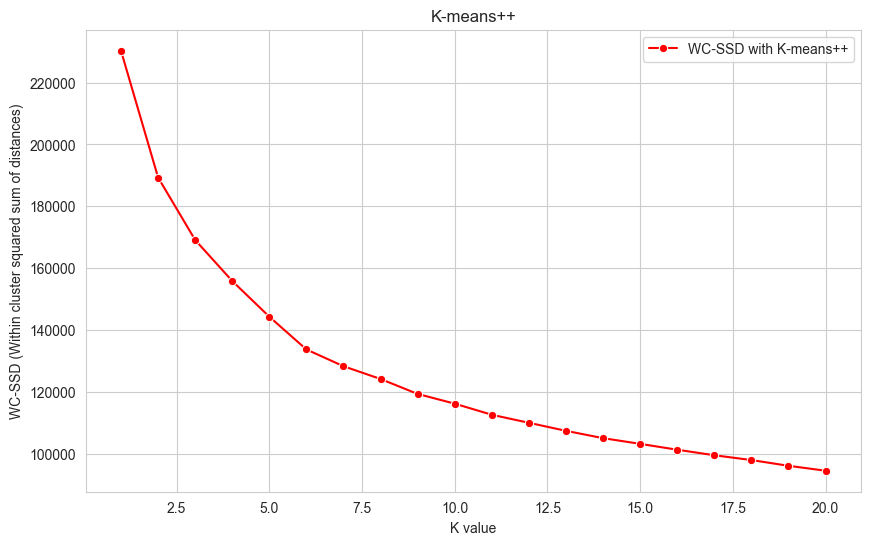

In [19]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

sns.lineplot(x=range(1,21), y=wcssd_scores[:], label="WC-SSD with K-means++", color="red", marker='o')

plt.xlabel("K value")
plt.ylabel("WC-SSD (Within cluster squared sum of distances)")
plt.title("K-means++")
plt.legend()
plt.show()

According to the elbow method, $k=6$ seems to be the optimal value of $k$ as at $k=6$ there is a steep change in the slope of the graph. Though we know that the optimal values of $k$ is $7$ in this case as this is the number of classes of the dataset. The reason behind $k=6$ coming up as the optimal value might be the fact that the dataset is unbalanced and we might not be getting enough points of some particular class in our $20,000$ randomly selected samples. Lets check this.

In [20]:
for i in range(1,8):
    print(f"For class {i} -> {np.sum(y==i)} points")

For class 1 -> 7120 points
For class 2 -> 9860 points
For class 3 -> 1244 points
For class 4 -> 83 points
For class 5 -> 329 points
For class 6 -> 653 points
For class 7 -> 711 points


So here our culprit is, since we have only $83$ points for class $4$, it is highly probable that our clustering is not going well. Also for Classes $5,6$ and $7$, very less points are there. Lets check the number of points in clusters created in case of $k=7$.

In [21]:
for i in range(7):
    print(f"For cluster {i+1} -> {np.sum(mappings_k_pp_7==i)} points")

For cluster 1 -> 1809 points
For cluster 2 -> 3594 points
For cluster 3 -> 1628 points
For cluster 4 -> 2382 points
For cluster 5 -> 5251 points
For cluster 6 -> 1954 points
For cluster 7 -> 3382 points


The number of points in these cluster do not agree with the number of points of each cluster we have. This shows that the K-means clustering is inefficient in this case.

Now, continuing with the tasks, doing the same for naive centroids initialization

In [22]:
#making list to score WC-SSD stores
wcssd_scores_naive_centroids = []

#removing the seed
random_generator = np.random.default_rng()


for k in range(1,21):
    wcssd = 0
    for i in range(10):
        initial_centroids = kmeans_plus_plus_init(X, k, random_generator, naive_centroids=True) #initializing naively
        centroids, mappings, squared_distances = k_means_clustering(X,X_norm_squared, initial_centroids, 500, to_print=False)
        wcssd_k_means_plus_plus = np.sum(squared_distances)
        wcssd += wcssd_k_means_plus_plus
    wcssd = wcssd/10
    wcssd_scores_naive_centroids.append(wcssd)
    print(f"Completed till k={k}")

Completed till k=1
Completed till k=2
Completed till k=3
Completed till k=4
Completed till k=5
Completed till k=6
Completed till k=7
Completed till k=8
Completed till k=9
Completed till k=10
Completed till k=11
Completed till k=12
Completed till k=13
Completed till k=14
Completed till k=15
Completed till k=16
Completed till k=17
Completed till k=18
Completed till k=19
Completed till k=20


Lets now plot them together and try to see the difference

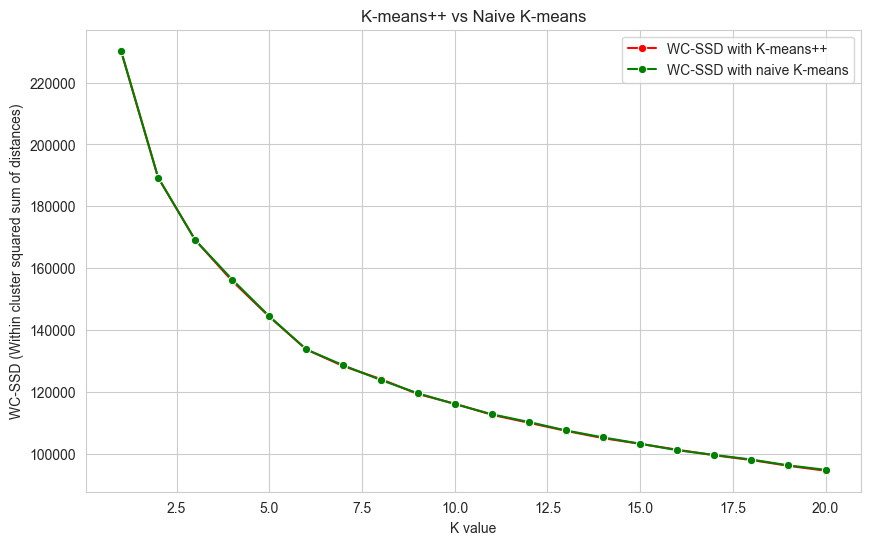

In [23]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

sns.lineplot(x=range(1,21), y=wcssd_scores[:], label="WC-SSD with K-means++", color="red", marker='o')
sns.lineplot(x=range(1,21), y=wcssd_scores_naive_centroids[:], label="WC-SSD with naive K-means", color="green", marker='o')

plt.xlabel("K value")
plt.ylabel("WC-SSD (Within cluster squared sum of distances)")
plt.title("K-means++ vs Naive K-means")
plt.legend()
plt.show()


The values seem to be quite similar and hence here $K$-means++ doesnt actually make much difference. Let us try to have a look at the difference between their WC-SSD scores for all the values of $k$.

In [24]:
diff_wcssd_scores = np.array(wcssd_scores) - np.array(wcssd_scores_naive_centroids)
diff_wcssd_scores

array([ 0.00000000e+00,  0.00000000e+00, -1.73867360e-04, -4.61906371e+02,
       -1.49113688e+02, -1.05333189e-01, -2.68985918e+02,  2.97337455e+02,
       -2.35312184e+02,  1.18716063e+02, -1.68540359e+02, -2.52934794e+02,
       -1.20774942e+02, -2.40785693e+02, -4.34073953e+01,  1.47445721e+02,
       -8.56357925e+01, -1.63647314e+02, -1.24314039e+02, -2.93458346e+02])

It is pretty obvious that the difference in WC-SSD scores is negative in most of the cases, or negligible, highlighting the fact that $K$-means++ is generally better than Naive $K$-means. Luckily, in this case Naive $K$-means happen to cluster effectively in all our runs, but there might be some other data where it might fail in some case, leading to inefficient clustering. In that case, $K$-means++ is the lifesaver as it has a lot more chances of achieving optimal clustering in all cases.

In [25]:
X_norm_squared.shape

(20000, 1)

In [32]:
np.sum(X**2, axis=1).reshape(20000,1)

array([[10.3997979 ],
       [ 8.36404742],
       [ 7.04939374],
       ...,
       [24.62788411],
       [ 7.18487979],
       [17.71595116]], shape=(20000, 1))